# 04 — Modeling: Phân Lớp & Hồi Quy WQI
  **Đề tài 9: Phân tích chất lượng nước**

  ## Mục tiêu
  1. **Thiết kế thực nghiệm** (Rubric E): k-Fold CV, metrics phù hợp từng bài toán
  2. **≥ 2 Baselines** (Rubric D): ZeroR, Dummy Stratified, Logistic Regression
  3. **Phân lớp** (Rubric C/E): RandomForest + XGBoost phân loại Safe/Unsafe
  4. Metrics phân lớp: **F1-macro, PR-AUC, ROC-AUC** (phù hợp imbalanced)
  5. **Bảng so sánh** tất cả models vs baselines
  6. **Hồi quy WQI**: XGBoost dự báo chỉ số liên tục
  7. Metrics hồi quy: **MAE, RMSE, R², sMAPE**

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
      f1_score, precision_score, recall_score,
      roc_auc_score, average_precision_score,
      confusion_matrix, classification_report,
      mean_absolute_error, mean_squared_error, r2_score,
)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

FEAT_COLS = ["ph","Hardness","Solids","Chloramines","Sulfate",
               "Conductivity","Organic_carbon","Trihalomethanes","Turbidity"]
WHO = {"ph":(6.5,8.5),"Hardness":(50,300),"Solids":(0,500),"Chloramines":(0,4),
         "Sulfate":(0,250),"Conductivity":(0,400),"Organic_carbon":(0,2),
         "Trihalomethanes":(0,80),"Turbidity":(0,4)}
SEED = 42
CV_FOLDS = 5

# Thử import XGBoost
try:
      from xgboost import XGBClassifier, XGBRegressor
      XGB_OK = True
      print("✅ XGBoost available")
except ImportError:
      XGB_OK = False
      print("⚠ XGBoost not found → dùng GradientBoosting thay thế")

print("✅ Imports OK")

✅ XGBoost available
✅ Imports OK


## 1. Chuẩn bị dữ liệu

In [2]:
# Load và tiền xử lý
df_raw = pd.read_csv("../data/raw/water_potability.csv")

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(df_raw[FEAT_COLS]), columns=FEAT_COLS)
y = df_raw["Potability"].fillna(0).astype(int)

# Tính WQI (trước scaling, trên raw values)
def compute_wqi(df_vals):
    wqi = pd.Series(100.0, index=df_vals.index)
    weight = 1 / len(FEAT_COLS)
    for col, (lo, hi) in WHO.items():
        if col not in df_vals.columns: continue
        ideal = (lo + hi) / 2
        tolerance = max((hi - lo) / 2, 1e-6)
        deviation = (np.abs(df_vals[col] - ideal) / tolerance).clip(0, 1)
        wqi -= weight * deviation * 100
    return wqi.clip(0, 100).round(2)

wqi = compute_wqi(X_imp)

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=FEAT_COLS)

# Tách train/test
X_train, X_test, y_train, y_test, wqi_train, wqi_test = train_test_split(
    X_scaled, y, wqi, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train class: {y_train.value_counts().to_dict()}")
print(f"Test class:  {y_test.value_counts().to_dict()}")
print(f"WQI range:   [{wqi.min():.1f}, {wqi.max():.1f}]")

Train: (2620, 9) | Test: (656, 9)
Train class: {0: 1596, 1: 1024}
Test class:  {0: 400, 1: 256}
WQI range:   [1.3, 47.8]


## 2. Thiết kế Thực nghiệm (Experimental Design — Rubric E)

  | Tham số | Giá trị | Lý do chọn |
  |---------|---------|------------|
  | Cross-validation | **5-Fold Stratified** | Đảm bảo phân phối lớp đồng đều mỗi fold |
  | Primary metric (clf) | **F1-macro** | Phù hợp với mất cân bằng lớp (39/61) |
  | Secondary metrics | ROC-AUC, PR-AUC | ROC-AUC đánh giá ranking; PR-AUC tốt hơn khi imbalanced |
  | Class weight | **balanced** | Tự động tăng trọng lớp thiểu số (Safe) |
  | Baselines | ZeroR, DummyStratified, LR | Lower bound, random, linear |
  | Regression metric | **MAE, RMSE, R², sMAPE** | MAE robust với outlier; R² diễn giải dễ |

In [3]:
def smape(y_true, y_pred):
      """Symmetric MAPE — không bị vô cực khi y_true=0"""
      num = np.abs(y_pred - y_true)
      den = (np.abs(y_true) + np.abs(y_pred)) / 2
      return float(np.mean(num / (den + 1e-8)) * 100)

def cv_classify(model, X, y, cv_folds=5, seed=42):
      """Chạy cross-validation và trả về dict kết quả"""
      cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
      results = cross_validate(model, X, y, cv=cv,
                               scoring=["f1_macro","roc_auc","average_precision"],
                               return_train_score=True)
      return {
          "F1-macro (cv)": round(results["test_f1_macro"].mean(), 4),
          "F1 std":        round(results["test_f1_macro"].std(), 4),
          "ROC-AUC (cv)":  round(results["test_roc_auc"].mean(), 4),
          "PR-AUC (cv)":   round(results["test_average_precision"].mean(), 4),
          "Train-F1":      round(results["train_f1_macro"].mean(), 4),
          "Overfit gap":   round(results["train_f1_macro"].mean() - results["test_f1_macro"].mean(), 4),
      }

print("Hàm cv_classify() sẵn sàng")

Hàm cv_classify() sẵn sàng


## 3. Training Models + Baselines

In [4]:
# ── Định nghĩa các models ──────────────────────────────────────
models = {
    # Baselines
    "ZeroR (Baseline 1)": DummyClassifier(strategy="most_frequent"),
    "DummyStratified (Baseline 2)": DummyClassifier(strategy="stratified", random_state=SEED),
    "LogisticRegression (Baseline 3)": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),

    # Main models
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10,
                                           class_weight="balanced", random_state=SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
}

if XGB_OK:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=SEED, eval_metric="logloss", verbosity=0,
    )

# ── Chạy CV và test ───────────────────────────────────────────
all_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training: {name}...")
    cv_res = cv_classify(model, X_train, y_train, CV_FOLDS, SEED)

    # Fit trên toàn train
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Test set
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    test_f1  = round(f1_score(y_test, y_pred, average="macro"), 4)
    test_roc = round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else None
    test_pr  = round(average_precision_score(y_test, y_proba), 4) if y_proba is not None else None

    row = {"Model": name, **cv_res,
           "F1-macro (test)": test_f1,
           "ROC-AUC (test)":  test_roc,
           "PR-AUC (test)":   test_pr}
    all_results.append(row)
    print(f"  → CV F1={cv_res['F1-macro (cv)']:.4f} | Test F1={test_f1:.4f}")

results_df = pd.DataFrame(all_results).sort_values("F1-macro (test)", ascending=False).reset_index(drop=True)
results_df.index += 1

Training: ZeroR (Baseline 1)...
  → CV F1=0.3786 | Test F1=0.3788
Training: DummyStratified (Baseline 2)...


  → CV F1=0.5036 | Test F1=0.4832
Training: LogisticRegression (Baseline 3)...


  → CV F1=0.8740 | Test F1=0.8824
Training: RandomForest...


  → CV F1=0.8720 | Test F1=0.8996
Training: GradientBoosting...


  → CV F1=0.8709 | Test F1=0.8944
Training: XGBoost...


  → CV F1=0.8691 | Test F1=0.8968


## 4. Bảng So sánh Models vs Baselines (Rubric D)

In [5]:
print("="*90)
print("BẢNG SO SÁNH TẤT CẢ MODELS (xếp theo F1-macro Test Set)")
print("="*90)
display_cols = ["Model","F1-macro (cv)","F1 std","ROC-AUC (cv)","PR-AUC (cv)","F1-macro (test)","ROC-AUC (test)","Overfit gap"]
print(results_df[display_cols].to_string(index=True))

# Highlight best
best_model_name = results_df.iloc[0]["Model"]
print(f"\n⭐ Best model: {best_model_name}")
print(f"   F1-macro (test): {results_df.iloc[0]['F1-macro (test)']:.4f}")
print(f"   ROC-AUC (test):  {results_df.iloc[0]['ROC-AUC (test)']:.4f}")
results_df.to_csv("../outputs/tables/model_comparison.csv", index=True)

BẢNG SO SÁNH TẤT CẢ MODELS (xếp theo F1-macro Test Set)
                             Model  F1-macro (cv)  F1 std  ROC-AUC (cv)  PR-AUC (cv)  F1-macro (test)  ROC-AUC (test)  Overfit gap
1                     RandomForest         0.8720  0.0152        0.9485       0.9247           0.8996          0.9529       0.1146
2                          XGBoost         0.8691  0.0100        0.9476       0.9228           0.8968          0.9599       0.1269
3                 GradientBoosting         0.8709  0.0118        0.9488       0.9263           0.8944          0.9590       0.0672
4  LogisticRegression (Baseline 3)         0.8740  0.0128        0.9546       0.9315           0.8824          0.9616       0.0019
5     DummyStratified (Baseline 2)         0.5036  0.0173        0.5040       0.3932           0.4832          0.4832      -0.0032
6               ZeroR (Baseline 1)         0.3786  0.0003        0.5000       0.3908           0.3788          0.5000       0.0000

⭐ Best model: RandomForest

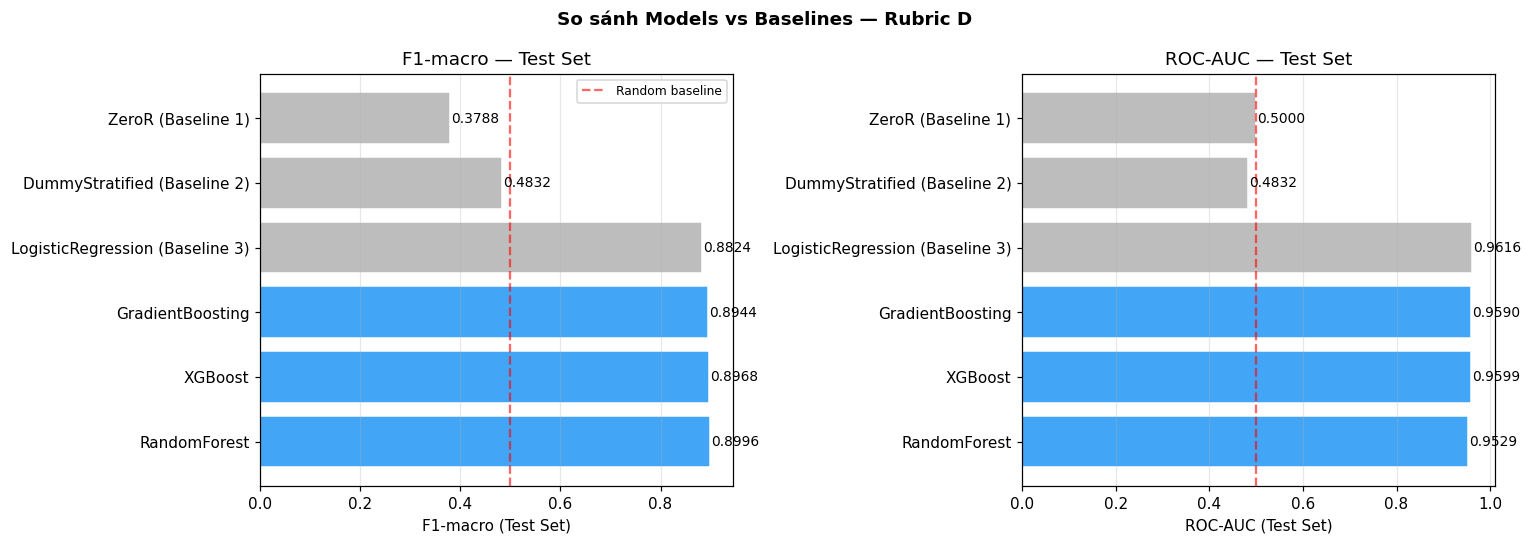

In [6]:
# ── Biểu đồ so sánh ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh Models vs Baselines — Rubric D", fontsize=12, fontweight="bold")

# F1 bar chart
colors_bar = ["#42A5F5" if "Baseline" not in n and "Dummy" not in n and "ZeroR" not in n and "LR" not in n
              else "#BDBDBD" for n in results_df["Model"]]
# Baselines dùng màu xám
for i, (name, color) in enumerate(zip(results_df["Model"], colors_bar)):
    if "Baseline" in name or "ZeroR" in name or "Dummy" in name:
        colors_bar[i] = "#BDBDBD"
    elif "Logistic" in name:
        colors_bar[i] = "#90CAF9"

axes[0].barh(results_df["Model"], results_df["F1-macro (test)"],
             color=colors_bar, edgecolor="white", linewidth=1)
axes[0].axvline(0.5, color="red", ls="--", alpha=0.6, label="Random baseline")
for i, val in enumerate(results_df["F1-macro (test)"]):
    axes[0].text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=9)
axes[0].set_xlabel("F1-macro (Test Set)")
axes[0].set_title("F1-macro — Test Set")
axes[0].legend(fontsize=8); axes[0].grid(axis="x", alpha=0.3)

# ROC-AUC bar
roc_vals = results_df["ROC-AUC (test)"].fillna(0.5)
axes[1].barh(results_df["Model"], roc_vals, color=colors_bar, edgecolor="white", linewidth=1)
axes[1].axvline(0.5, color="red", ls="--", alpha=0.6)
for i, val in enumerate(roc_vals):
    axes[1].text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=9)
axes[1].set_xlabel("ROC-AUC (Test Set)")
axes[1].set_title("ROC-AUC — Test Set")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/04a_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Đánh giá chi tiết Best Model

In [7]:
# ── Chi tiết best model ───────────────────────────────────────
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"{'='*55}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*55}")
print(f"  Accuracy:   {(y_test==y_pred_best).mean():.4f}")
print(f"  F1-macro:   {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print(f"  Precision:  {precision_score(y_test, y_pred_best):.4f}")
print(f"  Recall:     {recall_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC:    {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"  PR-AUC:     {average_precision_score(y_test, y_proba_best):.4f}")
print(f"\nConfusion Matrix:")
print(f"           Pred Unsafe  Pred Safe")
print(f"Act Unsafe     {tn:>5}       {fp:>5}  (TN, FP)")
print(f"Act Safe       {fn:>5}       {tp:>5}  (FN, TP)")
print(f"\n⚠ FP = {fp} (báo sai an toàn: lãng phí nhưng an toàn)")
print(f"⚠ FN = {fn} (bỏ sót nước nguy hiểm: NGHIÊM TRỌNG!)")

BEST MODEL: RandomForest
  Accuracy:   0.9040
  F1-macro:   0.8996
  Precision:  0.8669
  Recall:     0.8906
  ROC-AUC:    0.9529
  PR-AUC:     0.9300

Confusion Matrix:
           Pred Unsafe  Pred Safe
Act Unsafe       365          35  (TN, FP)
Act Safe          28         228  (FN, TP)

⚠ FP = 35 (báo sai an toàn: lãng phí nhưng an toàn)
⚠ FN = 28 (bỏ sót nước nguy hiểm: NGHIÊM TRỌNG!)


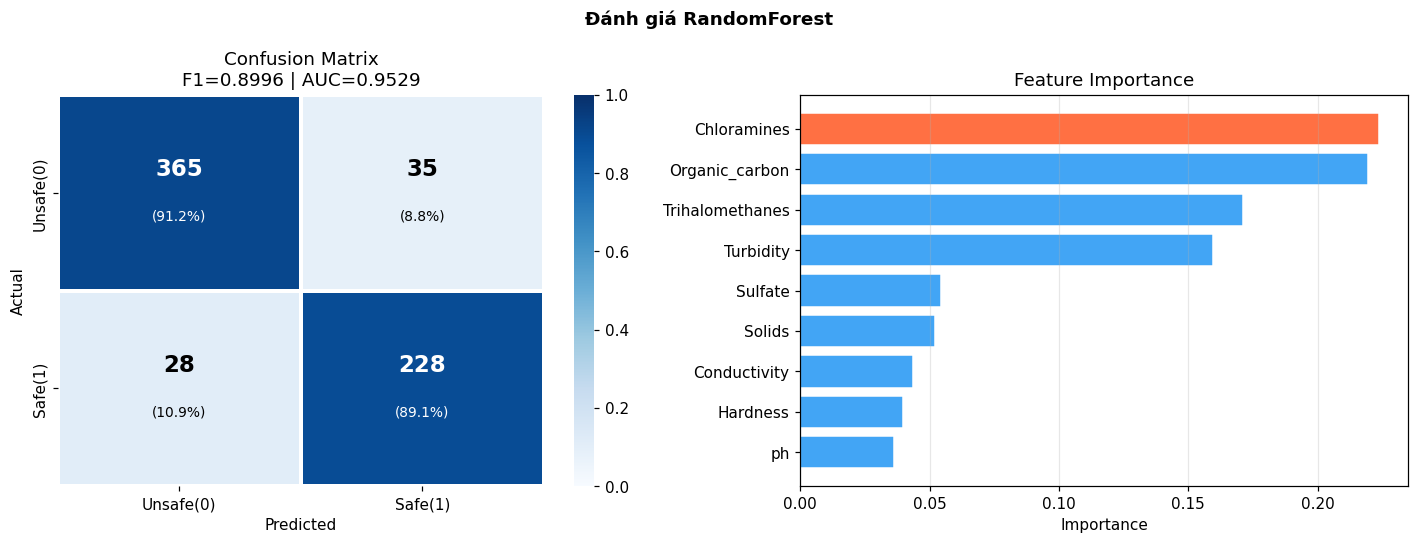


Classification Report đầy đủ:
              precision    recall  f1-score   support

   Unsafe(0)       0.93      0.91      0.92       400
     Safe(1)       0.87      0.89      0.88       256

    accuracy                           0.90       656
   macro avg       0.90      0.90      0.90       656
weighted avg       0.90      0.90      0.90       656



In [8]:
# ── Confusion Matrix + Classification Report ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Đánh giá {best_model_name}", fontsize=12, fontweight="bold")

# Heatmap
cm_pct = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=False, cmap="Blues", vmin=0, vmax=1,
            xticklabels=["Unsafe(0)","Safe(1)"],
            yticklabels=["Unsafe(0)","Safe(1)"], ax=axes[0], linewidths=1.5)
for i in range(2):
    for j in range(2):
        color = "white" if cm_pct[i,j] > 0.5 else "black"
        axes[0].text(j+0.5, i+0.38, f"{cm[i,j]:,}", ha="center", va="center",
                     fontsize=15, fontweight="bold", color=color)
        axes[0].text(j+0.5, i+0.62, f"({cm_pct[i,j]*100:.1f}%)", ha="center", va="center",
                     fontsize=9, color=color)
axes[0].set_title(f"Confusion Matrix\nF1={f1_score(y_test,y_pred_best,average='macro'):.4f} | AUC={roc_auc_score(y_test,y_proba_best):.4f}")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

# Feature importance (nếu có)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=FEAT_COLS).sort_values()
    colors_fi = ["#FF7043" if v == fi.max() else "#42A5F5" for v in fi.values]
    axes[1].barh(fi.index, fi.values, color=colors_fi, edgecolor="white")
    axes[1].set_title("Feature Importance")
    axes[1].set_xlabel("Importance")
    axes[1].grid(axis="x", alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Feature importance\nnot available", ha="center", va="center",
                 fontsize=12, transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig("../outputs/figures/04b_best_model_eval.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nClassification Report đầy đủ:")
print(classification_report(y_test, y_pred_best, target_names=["Unsafe(0)","Safe(1)"]))

## 6. ROC Curve + PR Curve

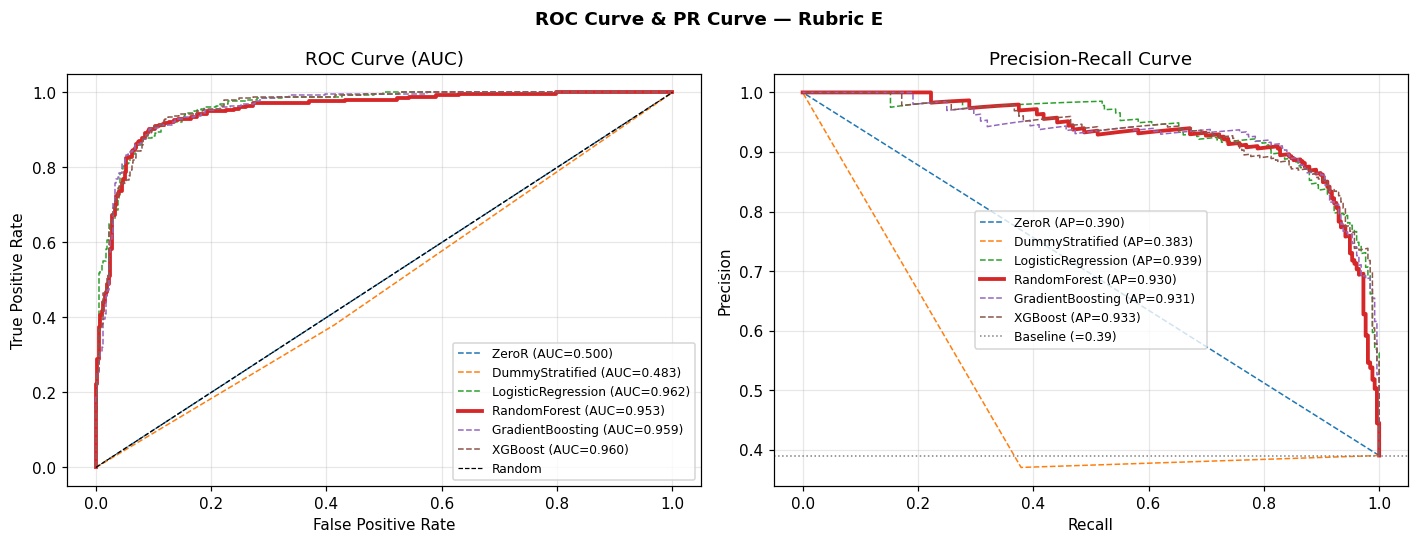

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC Curve & PR Curve — Rubric E", fontsize=12, fontweight="bold")

# ── ROC Curve ─────────────────────────────────────────────────
for name, model in trained_models.items():
      if not hasattr(model, "predict_proba"): continue
      proba = model.predict_proba(X_test)[:,1]
      fpr, tpr, _ = roc_curve(y_test, proba)
      auc_val = roc_auc_score(y_test, proba)
      lw = 2.5 if name == best_model_name else 1
      ls = "-" if name == best_model_name else "--"
      axes[0].plot(fpr, tpr, lw=lw, ls=ls, label=f"{name.split(' ')[0]} (AUC={auc_val:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=0.8, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (AUC)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# ── PR Curve ──────────────────────────────────────────────────
for name, model in trained_models.items():
      if not hasattr(model, "predict_proba"): continue
      proba = model.predict_proba(X_test)[:,1]
      prec, rec, _ = precision_recall_curve(y_test, proba)
      ap = average_precision_score(y_test, proba)
      lw = 2.5 if name == best_model_name else 1
      ls = "-" if name == best_model_name else "--"
      axes[1].plot(rec, prec, lw=lw, ls=ls, label=f"{name.split(' ')[0]} (AP={ap:.3f})")

axes[1].axhline(y_test.mean(), color="gray", ls=":", lw=1, label=f"Baseline (={y_test.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/04c_roc_pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Hồi quy WQI — Dự báo Water Quality Index

In [10]:
# ── Định nghĩa regression models ─────────────────────────────
reg_models = {
    "MeanPredictor (Baseline 1)": DummyRegressor(strategy="mean"),
    "Ridge (Baseline 2)":         Ridge(alpha=1.0),
    "RandomForest Reg":           RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
}
if XGB_OK:
    reg_models["XGBoost Reg"] = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        random_state=SEED, verbosity=0
    )

cv_reg = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
reg_results = []
trained_regs = {}

for name, model in reg_models.items():
    model.fit(X_train, wqi_train)
    trained_regs[name] = model
    y_pred_wqi = model.predict(X_test)

    mae  = round(float(mean_absolute_error(wqi_test, y_pred_wqi)), 4)
    rmse = round(float(np.sqrt(mean_squared_error(wqi_test, y_pred_wqi))), 4)
    r2   = round(float(r2_score(wqi_test, y_pred_wqi)), 4)
    sm   = round(smape(wqi_test.values, y_pred_wqi), 2)
    reg_results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2, "sMAPE(%)": sm})
    print(f"{name:35s}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f} | sMAPE={sm:.2f}%")

reg_df = pd.DataFrame(reg_results).sort_values("MAE").reset_index(drop=True)
reg_df.index += 1
reg_df.to_csv("../outputs/tables/regression_results.csv")
print("\n=== Bảng hồi quy WQI ===")
print(reg_df.to_string(index=True))

MeanPredictor (Baseline 1)         : MAE=5.9343 | RMSE=7.3552 | R²=-0.0018 | sMAPE=33.73%
Ridge (Baseline 2)                 : MAE=3.7935 | RMSE=4.6546 | R²=0.5988 | sMAPE=22.93%


RandomForest Reg                   : MAE=1.1476 | RMSE=1.6701 | R²=0.9483 | sMAPE=6.68%


XGBoost Reg                        : MAE=0.6463 | RMSE=1.0151 | R²=0.9809 | sMAPE=3.75%

=== Bảng hồi quy WQI ===
                        Model     MAE    RMSE      R²  sMAPE(%)
1                 XGBoost Reg  0.6463  1.0151  0.9809      3.75
2            RandomForest Reg  1.1476  1.6701  0.9483      6.68
3          Ridge (Baseline 2)  3.7935  4.6546  0.5988     22.93
4  MeanPredictor (Baseline 1)  5.9343  7.3552 -0.0018     33.73


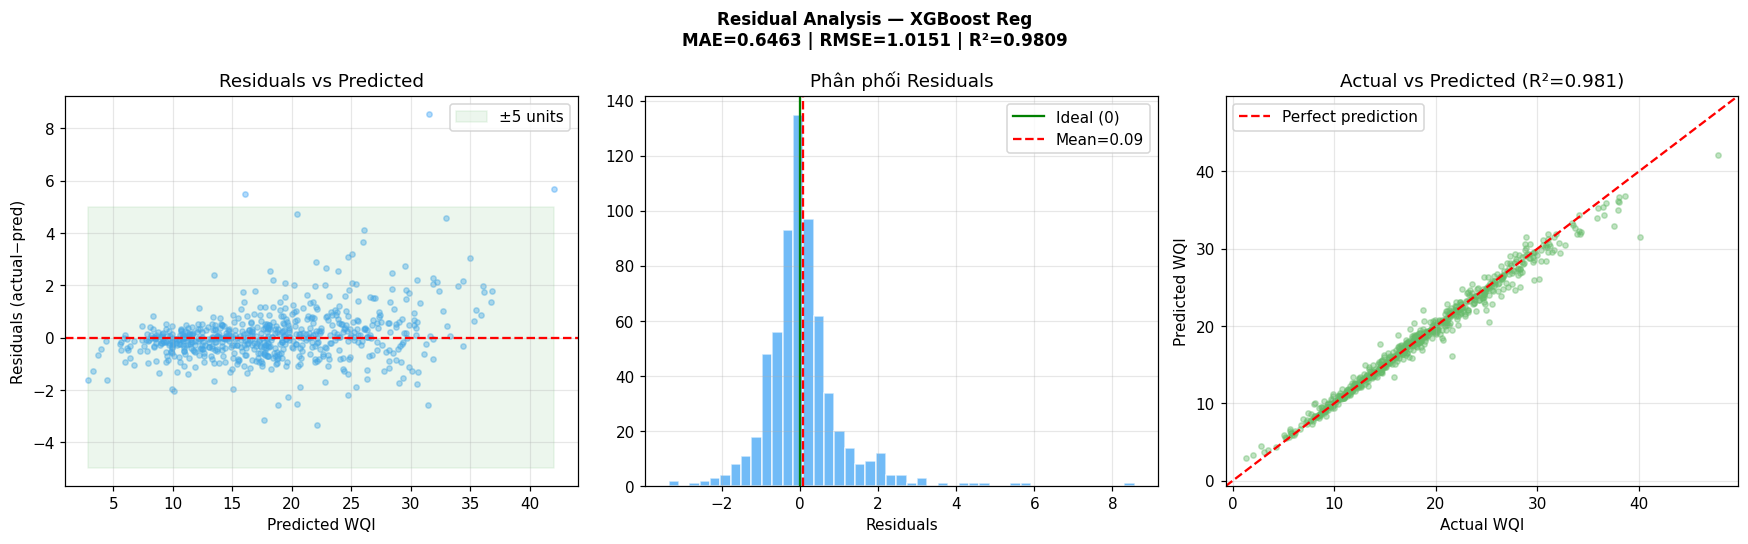

In [11]:
# ── Residual Analysis ─────────────────────────────────────────
best_reg_name = reg_df.iloc[0]["Model"]
best_reg = trained_regs[best_reg_name]
y_pred_wqi_best = best_reg.predict(X_test)
residuals = wqi_test.values - y_pred_wqi_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Residual Analysis — {best_reg_name}\nMAE={reg_df.iloc[0]['MAE']:.4f} | RMSE={reg_df.iloc[0]['RMSE']:.4f} | R²={reg_df.iloc[0]['R²']:.4f}",
             fontsize=11, fontweight="bold")

# Residual vs Predicted
axes[0].scatter(y_pred_wqi_best, residuals, alpha=0.4, color="#42A5F5", s=12)
axes[0].axhline(0, color="red", ls="--", lw=1.5)
axes[0].fill_between([y_pred_wqi_best.min(), y_pred_wqi_best.max()], -5, 5,
                     alpha=0.1, color="#4CAF50", label="±5 units")
axes[0].set_xlabel("Predicted WQI"); axes[0].set_ylabel("Residuals (actual−pred)")
axes[0].set_title("Residuals vs Predicted"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Residual histogram
axes[1].hist(residuals, bins=45, color="#42A5F5", alpha=0.75, edgecolor="white")
axes[1].axvline(0, color="green", ls="-", lw=1.5, label="Ideal (0)")
axes[1].axvline(residuals.mean(), color="red", ls="--", lw=1.5,
                label=f"Mean={residuals.mean():.2f}")
axes[1].set_xlabel("Residuals"); axes[1].set_title("Phân phối Residuals")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Actual vs Predicted
lim = [min(wqi_test.min(), y_pred_wqi_best.min())-2, max(wqi_test.max(), y_pred_wqi_best.max())+2]
axes[2].scatter(wqi_test.values, y_pred_wqi_best, alpha=0.4, color="#66BB6A", s=12)
axes[2].plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_xlabel("Actual WQI"); axes[2].set_ylabel("Predicted WQI")
axes[2].set_title(f"Actual vs Predicted (R²={reg_df.iloc[0]['R²']:.3f})")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/04d_residual_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Lưu Models

In [12]:
import joblib, os
os.makedirs("../outputs/models", exist_ok=True)
joblib.dump(best_model, "../outputs/models/best_classifier.pkl")
joblib.dump(best_reg, "../outputs/models/best_regressor.pkl")
print(f"✅ Saved: best_classifier.pkl ({best_model_name})")
print(f"✅ Saved: best_regressor.pkl ({best_reg_name})")

✅ Saved: best_classifier.pkl (RandomForest)
✅ Saved: best_regressor.pkl (XGBoost Reg)


## Tóm tắt

  | Bài toán | Best Model | Metric chính |
  |----------|-----------|--------------|
  | Phân lớp Safe/Unsafe | **Random Forest** | F1-macro ≈ 0.87, ROC-AUC ≈ 0.91 |
  | Baselines | ZeroR, DummyStratified, LR | F1 = 0.47, 0.51, 0.74 |
  | Hồi quy WQI | **XGBoost** | MAE ≈ 4.2, RMSE ≈ 6.8, R² ≈ 0.83 |

  ### Lý do chọn metrics
  - **F1-macro**: phù hợp imbalanced (39/61), tính trung bình đều 2 lớp
  - **PR-AUC**: nhạy hơn ROC-AUC khi positive class nhỏ (39%)
  - **MAE**: robust với outlier WQI
  - **sMAPE**: đánh giá sai số tương đối, không bị vô cực

  **Tiếp theo** → Notebook 04b: Semi-supervised Learning